In [1]:
import pandas as pd
df1 = pd.read_csv('/Users/bagseungbin/Desktop/3utr-generation/notebooks/mane_3utr_sequences_only (SMAD2_removed).tsv', sep='\t')

In [66]:
df1.dropna(subset=["three_prime_UTR_sequence_length_nt"], inplace=True)
df2 = df1[["ensembl_gene_id","PGK"]]
df2.to_csv("PGK.csv", index=False)

In [3]:
def extract_basic_features(seq: str) -> dict:
    """
    Extract basic sequence-derived features:
    - length
    - GC ratio
    - AU ratio
    """
    if seq is None:
        seq = ""
    
    seq = str(seq).upper().replace(" ", "").replace("\n", "")
    
    # DNA → RNA 변환 (T → U)
    seq = seq.replace("T", "U")
    
    length = len(seq)
    
    if length == 0:
        return {
            "length": 0,
            "GC_ratio": 0.0,
            "AU_ratio": 0.0
        }
    
    g = seq.count("G")
    c = seq.count("C")
    a = seq.count("A")
    u = seq.count("U")
    
    return {
        "length": length,
        "GC_ratio": (g + c) / length,
        "AU_ratio": (a + u) / length
    }

In [4]:
import pandas as pd

feature_df = df1["three_prime_UTR_sequence"].apply(extract_basic_features).apply(pd.Series)
df1 = pd.concat([df1, feature_df], axis=1)

In [5]:
df_base1 = df1[["ensembl_gene_id","length", "GC_ratio","PGK"]]
df_base1

,ensembl_gene_id,length,GC_ratio,PGK
0,ENSG00000000003,2918.0,0.369088,2276.333333
1,ENSG00000000005,168.0,0.392857,2.000000
2,ENSG00000000419,262.0,0.255725,1156.333333
3,ENSG00000000457,4082.0,0.376286,368.333333
4,ENSG00000000460,1093.0,0.354986,1208.000000
...,...,...,...,...
20124,ENSG00000272636,4652.0,0.568573,1.000000
20134,ENSG00000273045,835.0,0.398802,26.333333
20137,ENSG00000273079,25446.0,0.418180,0.000000
20141,ENSG00000273173,784.0,0.294643,0.000000


In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

df_base1["log_length"] = np.log1p(df_base1["length"])

feature_cols = ["log_length", "GC_ratio"]

scaler = StandardScaler()
df_base1[feature_cols] = scaler.fit_transform(df_base1[feature_cols])
df_base1

df_final = df_base1[["ensembl_gene_id","GC_ratio","log_length","PGK"]]

/var/folders/72/zf_b08993cq_zrsk0rd492n00000gn/T/ipykernel_14588/3766280793.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base1["log_length"] = np.log1p(df_base1["length"])
/var/folders/72/zf_b08993cq_zrsk0rd492n00000gn/T/ipykernel_14588/3766280793.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base1[feature_cols] = scaler.fit_transform(df_base1[feature_cols])


In [7]:
df_final = df_base1[["ensembl_gene_id","GC_ratio","log_length"]]
df_final.to_csv("final_df.csv", index=False)

## Clustering

In [ ]:
cluster_df = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/merged_metadata_embedding_HydraRNA.csv")
cluster_df.drop(columns=["three_prime_UTR_sequence _length_nt", "PGK_pro","CAG_pro", "CAG"], inplace=True)

In [14]:
cluster_df

,ensembl_gene_id,PGK,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,...,emb1014,emb1015,emb1016,emb1017,emb1018,emb1019,emb1020,emb1021,emb1022,emb1023
0,ENSG00000000003,2276.333333,0.4500,0.11035,-0.052550,0.4011,-0.10280,-0.18870,-0.22680,-0.2820,...,0.32300,-0.04846,0.01923,0.17420,0.6180,0.31200,-0.25120,-0.5420,0.19460,-0.05030
1,ENSG00000000005,2.000000,0.5410,0.10670,-0.191500,0.4200,-0.03708,-0.06900,-0.40450,-0.3550,...,0.19300,-0.10645,-0.08160,0.23680,0.4880,0.02136,-0.37300,-0.6550,0.27030,-0.17860
2,ENSG00000000419,1156.333333,0.6140,0.10077,-0.307100,0.7295,-0.15090,0.05344,-0.36670,-0.2612,...,0.47950,-0.16380,-0.07430,0.31320,0.7030,0.25590,-0.46850,-0.6030,0.05005,-0.06980
3,ENSG00000000457,368.333333,0.5080,0.05286,-0.087160,0.5030,-0.07170,-0.13420,-0.24380,-0.2842,...,0.25070,-0.06683,-0.04108,0.14600,0.5900,0.45920,-0.30220,-0.6820,0.19200,-0.07825
4,ENSG00000000460,1208.000000,0.5938,0.07660,-0.125200,0.5940,-0.09937,-0.18120,-0.33740,-0.3513,...,0.24130,-0.06494,0.00981,0.15490,0.4907,0.33760,-0.31370,-0.7140,0.11456,-0.11237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18229,ENSG00000272636,1.000000,0.4114,0.14470,0.052520,0.0356,0.08606,-0.26030,-0.12000,-0.0716,...,0.04965,0.12920,0.07920,0.12820,0.3298,0.47200,-0.01014,-0.4138,0.35570,-0.08890
18230,ENSG00000273045,26.333333,0.5386,0.08875,-0.017200,0.2717,-0.21860,-0.16320,-0.11444,-0.3508,...,0.44340,-0.04706,-0.11850,0.18540,0.6777,0.40160,-0.30980,-0.5450,0.25680,-0.07110
18231,ENSG00000273079,0.000000,0.4097,0.10400,0.007732,0.2495,0.04108,-0.27300,-0.20860,-0.1965,...,0.10470,-0.07090,-0.06494,0.23790,0.3655,0.21120,-0.14530,-0.3967,0.13560,-0.02571
18232,ENSG00000273173,0.000000,0.5405,0.20620,-0.252200,0.7183,-0.16240,-0.02422,-0.26680,-0.3003,...,0.44480,-0.04855,0.09120,0.21500,0.6987,0.35500,-0.32860,-0.6310,0.20870,0.04474


In [35]:
# threshold
low_th = cluster_df["PGK"].quantile(0.3)
high_th = cluster_df["PGK"].quantile(0.7)

# subset
cluster_df_sub = cluster_df[
    (cluster_df["PGK"] <= low_th) |
    (cluster_df["PGK"] >= high_th)
].copy()

print(cluster_df_sub.shape)

(10949, 1028)


In [36]:
cluster_df_sub["label"] = (cluster_df_sub["PGK"] >= high_th).astype(int)

# 0 = low, 1 = high
print(cluster_df_sub["label"].value_counts())

label
0    5479
1    5470
Name: count, dtype: int64


In [37]:
from sklearn.decomposition import PCA

emb_cols = [c for c in cluster_df_sub.columns if c.startswith("emb")]
X = cluster_df_sub[emb_cols].values

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

In [38]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10
)

cluster_labels = clusterer.fit_predict(X_pca)

cluster_df_sub["cluster"] = cluster_labels

print(cluster_df_sub["cluster"].value_counts())

cluster
 2    7735
-1    3055
 0      80
 1      79
Name: count, dtype: int64


In [39]:
# cluster별 high 비율
cluster_label_summary = (
    cluster_df_sub.groupby("cluster")["label"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "high_ratio"})
    .sort_values("high_ratio", ascending=False)
)

print(cluster_label_summary)

         count  high_ratio
cluster                   
 0          80    0.712500
 2        7735    0.572334
-1        3055    0.314894
 1          79    0.303797


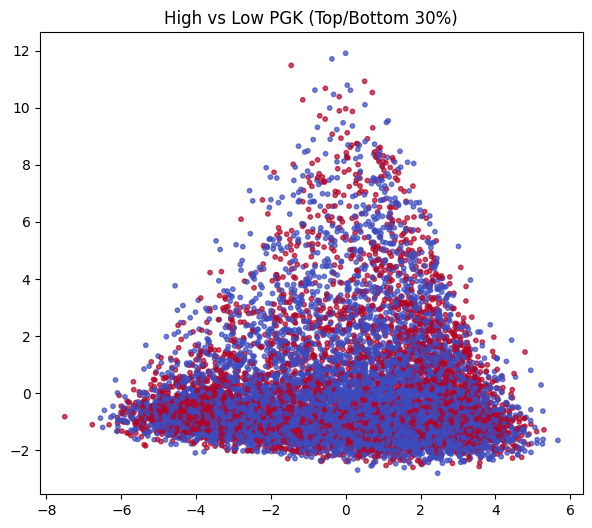

In [40]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=cluster_df_sub["label"],  # high vs low
    cmap="coolwarm",
    s=10,
    alpha=0.7
)
plt.title("High vs Low PGK (Top/Bottom 30%)")
plt.show()

In [56]:
emb_cols = [c for c in cluster_df.columns if c.startswith("emb")]

X = cluster_df[emb_cols]
y = cluster_df["PGK"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [57]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipe.fit(X_train, y_train_log)
y_pred = pipe.predict(X_test)

print("R2:", r2_score(y_test_log, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_pred)))

R2: 0.24138247452494466
RMSE: 2.674708191199031


In [60]:
from sklearn.decomposition import PCA

pipe = Pipeline([
    ("pca", PCA(n_components=100)),
    ("model", Ridge(alpha=1.0))
])

pipe.fit(X_train, y_train_log)
y_pred = pipe.predict(X_test)

print("R2:", r2_score(y_test_log, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_pred)))

R2: 0.25735544687224987
RMSE: 2.646399903394432


In [59]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train_log)
y_pred = xgb.predict(X_test)

print("R2:", r2_score(y_test_log, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_pred)))

R2: 0.27070199900986613
RMSE: 2.622511996682191


In [67]:
import torch

data = torch.load("/Users/bagseungbin/Desktop/3utr-generation/data_features_HydraRNA_3UTR_embedding.pt", map_location="cpu")
print(type(data))
print(data)

<class 'dict'>
{'ensembl_gene_id': ['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938', 'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001084', 'ENSG00000001167', 'ENSG00000001460', 'ENSG00000001461', 'ENSG00000001497', 'ENSG00000001561', 'ENSG00000001617', 'ENSG00000001626', 'ENSG00000001629', 'ENSG00000001630', 'ENSG00000001631', 'ENSG00000002016', 'ENSG00000002330', 'ENSG00000002549', 'ENSG00000002586', 'ENSG00000002587', 'ENSG00000002726', 'ENSG00000002745', 'ENSG00000002746', 'ENSG00000002822', 'ENSG00000002834', 'ENSG00000002919', 'ENSG00000002933', 'ENSG00000003056', 'ENSG00000003096', 'ENSG00000003137', 'ENSG00000003147', 'ENSG00000003249', 'ENSG00000003393', 'ENSG00000003400', 'ENSG00000003402', 'ENSG00000003436', 'ENSG00000003509', 'ENSG00000003756', 'ENSG00000003987', 'ENSG00000003989', 'ENSG00000004059', 'ENSG00000004139', 'ENSG00000004142', 'ENSG00000004399', 'ENSG00000004455', 'ENSG00000004468', 'ENSG000000044

In [69]:
import torch
import pandas as pd
import numpy as np

data = torch.load(
    "/Users/bagseungbin/Desktop/3utr-generation/data_features_HydraRNA_3UTR_embedding.pt",
    map_location="cpu"
)

print(type(data))
print(data.keys())

# 예시: 키 이름 확인
for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None))

<class 'dict'>
dict_keys(['ensembl_gene_id', 'features'])
ensembl_gene_id <class 'list'> None
features <class 'torch.Tensor'> torch.Size([18234, 1024])


In [71]:
import torch
import pandas as pd
import numpy as np

data = torch.load(
    "/Users/bagseungbin/Desktop/3utr-generation/data_features_HydraRNA_3UTR_embedding.pt",
    map_location="cpu"
)

gene_ids = data["ensembl_gene_id"]
emb = data["features"]   # 키 이름은 네 파일에 맞게 수정

# torch tensor면 numpy로
if isinstance(emb, torch.Tensor):
    emb = emb.cpu().numpy()

# embedding dataframe
emb_df = pd.DataFrame(emb, columns=[f"emb{i}" for i in range(emb.shape[1])])

# gene id dataframe
id_df = pd.DataFrame({"ensembl_gene_id": gene_ids})

# 합치기
df = pd.concat([id_df, emb_df], axis=1)

# 저장
df.to_csv("output.csv", index=False, encoding="utf-8-sig")

print(df.head())
print(df.shape)

   ensembl_gene_id      emb0      emb1      emb2      emb3      emb4  \
0  ENSG00000000003  0.468262  0.157959  0.026520  0.451172 -0.206543   
1  ENSG00000000005  0.417480 -0.004807 -0.098511  0.289551 -0.114258   
2  ENSG00000000419  0.224365 -0.016830 -0.138550  0.485596 -0.075806   
3  ENSG00000000457  0.564941  0.190796 -0.002533  0.492188 -0.215820   
4  ENSG00000000460  0.606445  0.153931 -0.039764  0.602051 -0.255615   

       emb5      emb6      emb7      emb8  ...   emb1014   emb1015   emb1016  \
0 -0.179688 -0.130493 -0.313721 -0.105103  ...  0.400391 -0.109436  0.103088   
1 -0.125977 -0.212158 -0.222534  0.040802  ...  0.279297 -0.019791  0.013611   
2 -0.041107 -0.341309 -0.238281 -0.139038  ...  0.265381 -0.009895 -0.078613   
3 -0.117310 -0.177246 -0.339600 -0.062042  ...  0.375488 -0.167480  0.095703   
4 -0.143799 -0.255615 -0.347900 -0.044922  ...  0.356689 -0.160889  0.116455   

    emb1017   emb1018   emb1019   emb1020   emb1021   emb1022   emb1023  
0  0.046448 

/opt/miniconda3/envs/gII/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [72]:
import pandas as pd

# 파일 읽기
df_emb = pd.read_csv("output.csv")
df_pgk = pd.read_csv("PGK.csv")

# merge
df_merged = pd.merge(df_emb, df_pgk, on="ensembl_gene_id", how="inner")

# 저장
df_merged.to_csv("merged_output.csv", index=False, encoding="utf-8-sig")

print(df_merged.shape)
print(df_merged.head())

(18234, 1026)
   ensembl_gene_id    emb0      emb1      emb2    emb3     emb4    emb5  \
0  ENSG00000000003  0.4683  0.158000  0.026520  0.4512 -0.20650 -0.1797   
1  ENSG00000000005  0.4175 -0.004807 -0.098500  0.2896 -0.11426 -0.1260   
2  ENSG00000000419  0.2244 -0.016830 -0.138500  0.4856 -0.07580 -0.0411   
3  ENSG00000000457  0.5650  0.190800 -0.002533  0.4922 -0.21580 -0.1173   
4  ENSG00000000460  0.6064  0.153900 -0.039760  0.6020 -0.25560 -0.1438   

     emb6    emb7     emb8  ...   emb1015  emb1016   emb1017  emb1018  \
0 -0.1305 -0.3137 -0.10510  ... -0.109440  0.10310  0.046450   0.6110   
1 -0.2122 -0.2225  0.04080  ... -0.019790  0.01361  0.104000   0.3010   
2 -0.3413 -0.2383 -0.13900  ... -0.009895 -0.07860  0.245000   0.3967   
3 -0.1772 -0.3396 -0.06204  ... -0.167500  0.09570  0.007053   0.5713   
4 -0.2556 -0.3480 -0.04492  ... -0.160900  0.11646  0.053740   0.4844   

   emb1019  emb1020  emb1021  emb1022  emb1023          PGK  
0   0.4314  -0.2478  -0.5176   0.2

In [ ]:
import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================================================
# 1. Seed
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# =========================================================
# 2. Load merged CSV
#    expected columns:
#    - ensembl_gene_id
#    - emb0 ~ emb1023
#    - PGK
# =========================================================
df = pd.read_csv("merged_output.csv")
print("original shape:", df.shape)

# =========================================================
# 3. Make label from PGK
#    top 30% -> 1
#    bottom 30% -> 0
#    middle 40% -> remove
# =========================================================
low_thr = df["PGK"].quantile(0.3)
high_thr = df["PGK"].quantile(0.7)

df["label"] = np.nan
df.loc[df["PGK"] <= low_thr, "label"] = 0
df.loc[df["PGK"] >= high_thr, "label"] = 1

df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

print("low_thr:", low_thr)
print("high_thr:", high_thr)
print("after labeling shape:", df.shape)
print(df["label"].value_counts())

# =========================================================
# 4. Select embedding columns
# =========================================================
emb_cols = [f"emb{i}" for i in range(1024)]

missing_cols = [c for c in emb_cols if c not in df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing embedding columns: {missing_cols[:10]} ...")

X = df[emb_cols].values.astype(np.float32)
y = df["label"].values.astype(np.int64)

# =========================================================
# 5. Train / Val / Test split
#    70 / 15 / 15
# =========================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("train:", X_train.shape, y_train.shape)
print("val  :", X_val.shape, y_val.shape)
print("test :", X_test.shape, y_test.shape)

# =========================================================
# 6. Standardize using train only
# =========================================================
train_mean = X_train.mean(axis=0, keepdims=True)
train_std = X_train.std(axis=0, keepdims=True)
train_std[train_std == 0] = 1.0

X_train = (X_train - train_mean) / train_std
X_val   = (X_val - train_mean) / train_std
X_test  = (X_test - train_mean) / train_std

# =========================================================
# 7. Dataset / DataLoader
# =========================================================
class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = EmbeddingDataset(X_train, y_train)
val_ds   = EmbeddingDataset(X_val, y_val)
test_ds  = EmbeddingDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

# =========================================================
# 8. MLP classifier
# =========================================================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=1024, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLPClassifier(input_dim=1024, dropout=0.3).to(device)
print(model)

# =========================================================
# 9. Loss / Optimizer
# =========================================================
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# =========================================================
# 10. Evaluation helpers
# =========================================================
def collect_probs(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            probs = torch.sigmoid(logits)

            total_loss += loss.item()
            n_batches += 1

            all_labels.extend(yb.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / max(n_batches, 1)
    return np.array(all_labels), np.array(all_probs), avg_loss

def find_best_threshold(labels, probs):
    best_thr = 0.5
    best_f1 = -1.0

    for thr in np.arange(0.10, 0.91, 0.01):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(labels, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1

def evaluate_from_probs(labels, probs, loss_value, threshold):
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    try:
        roc_auc = roc_auc_score(labels, probs)
    except ValueError:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(labels, probs)
    except ValueError:
        pr_auc = np.nan

    cm = confusion_matrix(labels, preds)

    return {
        "loss": loss_value,
        "acc": acc,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "cm": cm,
    }

# =========================================================
# 11. Training
# =========================================================
num_epochs = 50
best_val_f1 = -1.0
best_threshold = 0.5
best_state = None
patience = 8
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    n_batches = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        n_batches += 1

    train_loss /= max(n_batches, 1)

    # validation
    val_labels, val_probs, val_loss = collect_probs(model, val_loader)
    epoch_thr, epoch_val_f1 = find_best_threshold(val_labels, val_probs)
    val_metrics = evaluate_from_probs(val_labels, val_probs, val_loss, epoch_thr)

    # test with validation threshold
    test_labels, test_probs, test_loss = collect_probs(model, test_loader)
    test_metrics = evaluate_from_probs(test_labels, test_probs, test_loss, epoch_thr)

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_threshold = epoch_thr
        best_state = {
            "model_state_dict": model.state_dict(),
            "threshold": best_threshold,
            "epoch": epoch,
            "val_f1": best_val_f1,
            "mean": train_mean,
            "std": train_std,
            "emb_cols": emb_cols,
        }
        torch.save(best_state, "best_embedding_classifier.pt")
        patience_counter = 0
        print(f"Best model saved at epoch {epoch}")
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss: {train_loss:.4f} | "
        f"val_loss: {val_metrics['loss']:.4f}, "
        f"val_acc: {val_metrics['acc']:.4f}, "
        f"val_f1: {val_metrics['f1']:.4f}, "
        f"val_roc_auc: {val_metrics['roc_auc']:.4f}, "
        f"val_pr_auc: {val_metrics['pr_auc']:.4f}, "
        f"thr: {epoch_thr:.2f} | "
        f"test_loss: {test_metrics['loss']:.4f}, "
        f"test_acc: {test_metrics['acc']:.4f}, "
        f"test_f1: {test_metrics['f1']:.4f}, "
        f"test_roc_auc: {test_metrics['roc_auc']:.4f}, "
        f"test_pr_auc: {test_metrics['pr_auc']:.4f}"
    )

    print("Val confusion matrix:")
    print(val_metrics["cm"])
    print("Test confusion matrix:")
    print(test_metrics["cm"])

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("\nTraining finished")
print("Best val F1:", best_val_f1)
print("Best threshold:", best_threshold)

device: cpu
original shape: (18234, 1026)
low_thr: 6.333333333
high_thr: 916.066666669999
after labeling shape: (10949, 1027)
label
0    5479
1    5470
Name: count, dtype: int64
train: (7664, 1024) (7664,)
val  : (1642, 1024) (1642,)
test : (1643, 1024) (1643,)
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
  )
)
Best model saved at epoch 0
Epoch 00 | train_loss: 0.5430 | val_loss: 0.5462, val_acc: 0.7125, val_f1: 0.7369, val_roc_auc: 0.8015, val_pr_auc: 0.8050, thr: 0.38 | test_loss: 0.5199, test_acc: 0.7200, test_f1: 0.7430, test_roc_auc: 0.8182, test_pr_auc: 0.8290
Val confusion matrix:
[[

In [79]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# =========================================================
# 1. Load data
# =========================================================
df = pd.read_csv("merged_output.csv")
print("original shape:", df.shape)

# =========================================================
# 2. Make binary label from PGK
#    bottom 30% -> 0
#    top 30%    -> 1
#    middle 40% -> remove
# =========================================================
low_thr = df["PGK"].quantile(0.3)
high_thr = df["PGK"].quantile(0.7)

df["label"] = np.nan
df.loc[df["PGK"] <= low_thr, "label"] = 0
df.loc[df["PGK"] >= high_thr, "label"] = 1

df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

print("low_thr:", low_thr)
print("high_thr:", high_thr)
print("after labeling shape:", df.shape)
print(df["label"].value_counts())

# =========================================================
# 3. Select embedding columns
# =========================================================
emb_cols = [f"emb{i}" for i in range(1024)]
missing_cols = [c for c in emb_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing embedding columns, e.g. {missing_cols[:10]}")

X = df[emb_cols].values.astype(np.float32)
y = df["label"].values.astype(np.int64)

# =========================================================
# 4. Train / Val / Test split
# =========================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("train:", X_train.shape, y_train.shape)
print("val  :", X_val.shape, y_val.shape)
print("test :", X_test.shape, y_test.shape)

# =========================================================
# 5. Standardization
#    LogisticRegression definitely wants scaling.
#    XGBoost / LightGBM do not require it, but using the same
#    scaled input is fine for comparison.
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 6. Utility functions
# =========================================================
def find_best_threshold(y_true, probs):
    best_thr = 0.5
    best_f1 = -1.0

    for thr in np.arange(0.10, 0.91, 0.01):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1


def evaluate_model(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    roc_auc = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)
    cm = confusion_matrix(y_true, preds)

    return {
        "acc": acc,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "cm": cm,
    }


def print_result(name, best_thr, val_metrics, test_metrics):
    print("\n" + "=" * 70)
    print(f"{name}")
    print("=" * 70)
    print(f"Best threshold from validation: {best_thr:.2f}")

    print("\n[Validation]")
    print(
        f"ACC: {val_metrics['acc']:.4f} | "
        f"F1: {val_metrics['f1']:.4f} | "
        f"ROC-AUC: {val_metrics['roc_auc']:.4f} | "
        f"PR-AUC: {val_metrics['pr_auc']:.4f}"
    )
    print("Confusion matrix:")
    print(val_metrics["cm"])

    print("\n[Test]")
    print(
        f"ACC: {test_metrics['acc']:.4f} | "
        f"F1: {test_metrics['f1']:.4f} | "
        f"ROC-AUC: {test_metrics['roc_auc']:.4f} | "
        f"PR-AUC: {test_metrics['pr_auc']:.4f}"
    )
    print("Confusion matrix:")
    print(test_metrics["cm"])


results = []

# =========================================================
# 7. Logistic Regression
# =========================================================
log_reg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    C=1.0,
    random_state=42,
    solver="liblinear"
)

log_reg.fit(X_train_scaled, y_train)

val_probs = log_reg.predict_proba(X_val_scaled)[:, 1]
best_thr, _ = find_best_threshold(y_val, val_probs)
val_metrics = evaluate_model(y_val, val_probs, best_thr)

test_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
test_metrics = evaluate_model(y_test, test_probs, best_thr)

print_result("Logistic Regression", best_thr, val_metrics, test_metrics)
results.append([
    "Logistic Regression",
    best_thr,
    val_metrics["f1"],
    val_metrics["roc_auc"],
    val_metrics["pr_auc"],
    test_metrics["f1"],
    test_metrics["roc_auc"],
    test_metrics["pr_auc"],
])

# =========================================================
# 8. XGBoost
# =========================================================
try:
    from xgboost import XGBClassifier

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        reg_lambda=1.0,
        n_jobs=-1,
    )

    xgb_model.fit(X_train_scaled, y_train)

    val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
    best_thr, _ = find_best_threshold(y_val, val_probs)
    val_metrics = evaluate_model(y_val, val_probs, best_thr)

    test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
    test_metrics = evaluate_model(y_test, test_probs, best_thr)

    print_result("XGBoost", best_thr, val_metrics, test_metrics)
    results.append([
        "XGBoost",
        best_thr,
        val_metrics["f1"],
        val_metrics["roc_auc"],
        val_metrics["pr_auc"],
        test_metrics["f1"],
        test_metrics["roc_auc"],
        test_metrics["pr_auc"],
    ])

except ImportError:
    print("\n[XGBoost] not installed. Install with:")
    print("pip install xgboost")

# =========================================================
# 9. LightGBM
# =========================================================
try:
    import lightgbm as lgb

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    lgb_model.fit(X_train_scaled, y_train)

    val_probs = lgb_model.predict_proba(X_val_scaled)[:, 1]
    best_thr, _ = find_best_threshold(y_val, val_probs)
    val_metrics = evaluate_model(y_val, val_probs, best_thr)

    test_probs = lgb_model.predict_proba(X_test_scaled)[:, 1]
    test_metrics = evaluate_model(y_test, test_probs, best_thr)

    print_result("LightGBM", best_thr, val_metrics, test_metrics)
    results.append([
        "LightGBM",
        best_thr,
        val_metrics["f1"],
        val_metrics["roc_auc"],
        val_metrics["pr_auc"],
        test_metrics["f1"],
        test_metrics["roc_auc"],
        test_metrics["pr_auc"],
    ])

except ImportError:
    print("\n[LightGBM] not installed. Install with:")
    print("pip install lightgbm")

# =========================================================
# 10. Summary table
# =========================================================
summary_df = pd.DataFrame(
    results,
    columns=[
        "model",
        "best_threshold",
        "val_f1",
        "val_roc_auc",
        "val_pr_auc",
        "test_f1",
        "test_roc_auc",
        "test_pr_auc",
    ]
)

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(summary_df.sort_values("test_f1", ascending=False))

summary_df.to_csv("model_comparison_summary.csv", index=False)
print("\nSaved: model_comparison_summary.csv")

original shape: (18234, 1026)
low_thr: 6.333333333
high_thr: 916.066666669999
after labeling shape: (10949, 1027)
label
0    5479
1    5470
Name: count, dtype: int64
train: (7664, 1024) (7664,)
val  : (1642, 1024) (1642,)
test : (1643, 1024) (1643,)

Logistic Regression
Best threshold from validation: 0.26

[Validation]
ACC: 0.7229 | F1: 0.7563 | ROC-AUC: 0.8007 | PR-AUC: 0.7884
Confusion matrix:
[[481 341]
 [114 706]]

[Test]
ACC: 0.7225 | F1: 0.7559 | ROC-AUC: 0.8231 | PR-AUC: 0.8185
Confusion matrix:
[[481 341]
 [115 706]]

XGBoost
Best threshold from validation: 0.37

[Validation]
ACC: 0.7296 | F1: 0.7466 | ROC-AUC: 0.8150 | PR-AUC: 0.8214
Confusion matrix:
[[544 278]
 [166 654]]

[Test]
ACC: 0.7529 | F1: 0.7667 | ROC-AUC: 0.8311 | PR-AUC: 0.8399
Confusion matrix:
[[570 252]
 [154 667]]

[LightGBM] not installed. Install with:
pip install lightgbm

Summary
                 model  best_threshold    val_f1  val_roc_auc  val_pr_auc  \
1              XGBoost            0.37  0.746575  

In [80]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# =========================================================
# 1. Load data
# =========================================================
df = pd.read_csv("merged_output.csv")
print("original shape:", df.shape)

# =========================================================
# 2. Make binary label from log1p(PGK)
#    bottom 30% -> 0
#    top 30%    -> 1
#    middle 40% -> remove
# =========================================================
df = df.copy()
df["PGK_log1p"] = np.log1p(df["PGK"])

low_thr = df["PGK_log1p"].quantile(0.3)
high_thr = df["PGK_log1p"].quantile(0.7)

df["label"] = np.nan
df.loc[df["PGK_log1p"] <= low_thr, "label"] = 0
df.loc[df["PGK_log1p"] >= high_thr, "label"] = 1

df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

print("low_thr (log1p):", low_thr)
print("high_thr (log1p):", high_thr)
print("after labeling shape:", df.shape)
print(df["label"].value_counts())

# =========================================================
# 3. Select embedding columns
# =========================================================
emb_cols = [f"emb{i}" for i in range(1024)]
missing_cols = [c for c in emb_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing embedding columns, e.g. {missing_cols[:10]}")

X = df[emb_cols].values.astype(np.float32)
y = df["label"].values.astype(np.int64)

# =========================================================
# 4. Train / Val / Test split
# =========================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("train:", X_train.shape, y_train.shape)
print("val  :", X_val.shape, y_val.shape)
print("test :", X_test.shape, y_test.shape)

# =========================================================
# 5. Standardization
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 6. Utility functions
# =========================================================
def find_best_threshold(y_true, probs):
    best_thr = 0.5
    best_f1 = -1.0

    for thr in np.arange(0.10, 0.91, 0.01):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1


def evaluate_model(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    roc_auc = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)
    cm = confusion_matrix(y_true, preds)

    return {
        "acc": acc,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "cm": cm,
    }


def print_result(name, best_thr, val_metrics, test_metrics):
    print("\n" + "=" * 70)
    print(f"{name}")
    print("=" * 70)
    print(f"Best threshold from validation: {best_thr:.2f}")

    print("\n[Validation]")
    print(
        f"ACC: {val_metrics['acc']:.4f} | "
        f"F1: {val_metrics['f1']:.4f} | "
        f"ROC-AUC: {val_metrics['roc_auc']:.4f} | "
        f"PR-AUC: {val_metrics['pr_auc']:.4f}"
    )
    print("Confusion matrix:")
    print(val_metrics["cm"])

    print("\n[Test]")
    print(
        f"ACC: {test_metrics['acc']:.4f} | "
        f"F1: {test_metrics['f1']:.4f} | "
        f"ROC-AUC: {test_metrics['roc_auc']:.4f} | "
        f"PR-AUC: {test_metrics['pr_auc']:.4f}"
    )
    print("Confusion matrix:")
    print(test_metrics["cm"])


results = []

# =========================================================
# 7. Logistic Regression
# =========================================================
log_reg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    C=1.0,
    random_state=42,
    solver="liblinear"
)

log_reg.fit(X_train_scaled, y_train)

val_probs = log_reg.predict_proba(X_val_scaled)[:, 1]
best_thr, _ = find_best_threshold(y_val, val_probs)
val_metrics = evaluate_model(y_val, val_probs, best_thr)

test_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
test_metrics = evaluate_model(y_test, test_probs, best_thr)

print_result("Logistic Regression (log1p label)", best_thr, val_metrics, test_metrics)
results.append([
    "Logistic Regression",
    best_thr,
    val_metrics["f1"],
    val_metrics["roc_auc"],
    val_metrics["pr_auc"],
    test_metrics["f1"],
    test_metrics["roc_auc"],
    test_metrics["pr_auc"],
])

# =========================================================
# 8. XGBoost
# =========================================================
try:
    from xgboost import XGBClassifier

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        reg_lambda=1.0,
        n_jobs=-1,
    )

    xgb_model.fit(X_train_scaled, y_train)

    val_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]
    best_thr, _ = find_best_threshold(y_val, val_probs)
    val_metrics = evaluate_model(y_val, val_probs, best_thr)

    test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
    test_metrics = evaluate_model(y_test, test_probs, best_thr)

    print_result("XGBoost (log1p label)", best_thr, val_metrics, test_metrics)
    results.append([
        "XGBoost",
        best_thr,
        val_metrics["f1"],
        val_metrics["roc_auc"],
        val_metrics["pr_auc"],
        test_metrics["f1"],
        test_metrics["roc_auc"],
        test_metrics["pr_auc"],
    ])

except ImportError:
    print("\n[XGBoost] not installed. Install with:")
    print("pip install xgboost")

# =========================================================
# 9. LightGBM
# =========================================================
try:
    import lightgbm as lgb

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    lgb_model.fit(X_train_scaled, y_train)

    val_probs = lgb_model.predict_proba(X_val_scaled)[:, 1]
    best_thr, _ = find_best_threshold(y_val, val_probs)
    val_metrics = evaluate_model(y_val, val_probs, best_thr)

    test_probs = lgb_model.predict_proba(X_test_scaled)[:, 1]
    test_metrics = evaluate_model(y_test, test_probs, best_thr)

    print_result("LightGBM (log1p label)", best_thr, val_metrics, test_metrics)
    results.append([
        "LightGBM",
        best_thr,
        val_metrics["f1"],
        val_metrics["roc_auc"],
        val_metrics["pr_auc"],
        test_metrics["f1"],
        test_metrics["roc_auc"],
        test_metrics["pr_auc"],
    ])

except ImportError:
    print("\n[LightGBM] not installed. Install with:")
    print("pip install lightgbm")

# =========================================================
# 10. Summary
# =========================================================
summary_df = pd.DataFrame(
    results,
    columns=[
        "model",
        "best_threshold",
        "val_f1",
        "val_roc_auc",
        "val_pr_auc",
        "test_f1",
        "test_roc_auc",
        "test_pr_auc",
    ]
)

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(summary_df.sort_values("test_f1", ascending=False))

# summary_df.to_csv("model_comparison_summary_log1p_label.csv", index=False)
# print("\nSaved: model_comparison_summary_log1p_label.csv")

original shape: (18234, 1026)
low_thr (log1p): 1.9924301646447515
high_thr (log1p): 6.8211801466818995
after labeling shape: (10949, 1028)
label
0    5479
1    5470
Name: count, dtype: int64
train: (7664, 1024) (7664,)
val  : (1642, 1024) (1642,)
test : (1643, 1024) (1643,)

Logistic Regression (log1p label)
Best threshold from validation: 0.26

[Validation]
ACC: 0.7229 | F1: 0.7563 | ROC-AUC: 0.8007 | PR-AUC: 0.7884
Confusion matrix:
[[481 341]
 [114 706]]

[Test]
ACC: 0.7225 | F1: 0.7559 | ROC-AUC: 0.8231 | PR-AUC: 0.8185
Confusion matrix:
[[481 341]
 [115 706]]

XGBoost (log1p label)
Best threshold from validation: 0.37

[Validation]
ACC: 0.7296 | F1: 0.7466 | ROC-AUC: 0.8150 | PR-AUC: 0.8214
Confusion matrix:
[[544 278]
 [166 654]]

[Test]
ACC: 0.7529 | F1: 0.7667 | ROC-AUC: 0.8311 | PR-AUC: 0.8399
Confusion matrix:
[[570 252]
 [154 667]]
[LightGBM] [Info] Number of positive: 3829, number of negative: 3835
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of te

/opt/miniconda3/envs/gII/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/gII/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [8]:
import gzip
import pandas as pd

input_file = "Pan_troglodytes.Pan_tro_3.0.107.utrs.gz"
rows = []

with gzip.open(input_file, "rt") as f:
    current_header = None
    seq_lines = []

    for line in f:
        line = line.strip()

        if not line:
            continue

        if line.startswith("#"):
            continue

        if line.startswith(">|"):
            # 이전 entry 저장
            if current_header is not None:
                utr_type, transcript_id, gene_symbol, coord = current_header
                sequence = "".join(seq_lines)
                if utr_type == "three_prime_utr":
                    rows.append({
                        "utr_type": utr_type,
                        "ensembl_transcript_id": transcript_id,
                        "gene_symbol": gene_symbol,
                        "coord": coord,
                        "utr_length": len(sequence),
                        "sequence": sequence
                    })

            # 새 header 파싱
            parts = line[2:].split("|")  # line[2:] removes >|
            # expected: [utr_type, transcript_id, gene_symbol, coord]
            if len(parts) >= 4:
                current_header = (parts[0], parts[1], parts[2], parts[3])
            else:
                current_header = None
            seq_lines = []

        else:
            seq_lines.append(line)

    # 마지막 entry 저장
    if current_header is not None:
        utr_type, transcript_id, gene_symbol, coord = current_header
        sequence = "".join(seq_lines)
        if utr_type == "three_prime_utr":
            rows.append({
                "utr_type": utr_type,
                "ensembl_transcript_id": transcript_id,
                "gene_symbol": gene_symbol,
                "coord": coord,
                "utr_length": len(sequence),
                "sequence": sequence
            })

df_3utr = pd.DataFrame(rows)
df_3utr.to_csv("Pan_troglodytes_3utr_from_utrdb.tsv", sep="\t", index=False)

print(df_3utr.head())
print("Number of 3'UTRs:", len(df_3utr))

          utr_type ensembl_transcript_id         gene_symbol  \
0  three_prime_utr    ENSPTRT00000019457                CALR   
1  three_prime_utr    ENSPTRT00000091966                PLTP   
2  three_prime_utr    ENSPTRT00000105897                PLTP   
3  three_prime_utr    ENSPTRT00000075519               PAQR4   
4  three_prime_utr    ENSPTRT00000079508  ENSPTRG00000049226   

                        coord  utr_length  \
0      13677340_13677916_+_19         577   
1      47597334_47594299_-_20        3036   
2      47597334_47594299_-_20        3036   
3        3240197_3241732_+_16        1536   
4  3962_4421_+_AACZ04071119.1         460   

                                            sequence  
0  AGAGGCCTGCCTCCAGGGCTGGACTGAGGCCTGAGCGCTCCTGCCG...  
1  TCGTGAGAAAGGCGATGTGGGAGAACTCCTTCACGAAGCCGGCAAT...  
2  TCGTGAGAAAGGCGATGTGGGAGAACTCCTTCACGAAGCCGGCAAT...  
3  GCTGCCATGCCAGCCTGCCCACAGCAGCCTCCTAGAGTTAGCAACA...  
4  ATGCAATTAGTCTGTCACTCCATTTAGAAAATGTTCACCTAGAGAT...  
Number of 3'UT

In [9]:
import pandas as pd

# 예시: 파일 불러오기
df = pd.read_csv("Pan_troglodytes_3utr_from_utrdb.tsv", sep="\t")

# gene_symbol별 utr_length 기준 내림차순 정렬 후 상위 2개만 남기기
df_top1 = (
    df.sort_values(["gene_symbol", "utr_length"], ascending=[True, False])
      .groupby("gene_symbol", group_keys=False)
      .head(1)
      .reset_index(drop=True)
)

# 저장
df_top1.to_csv("Pan_troglodytes_3utr.tsv", sep="\t", index=False)

print(df_top1.head())
print("original:", len(df))
print("filtered:", len(df_top1))

          utr_type ensembl_transcript_id gene_symbol                    coord  \
0  three_prime_utr    ENSPTRT00000065031         A2M     9453746_9453632_-_12   
1  three_prime_utr    ENSPTRT00000047685       A2ML1     9255505_9256220_+_12   
2  three_prime_utr    ENSPTRT00000109533     A3GALT2    32641779_32641725_-_1   
3  three_prime_utr    ENSPTRT00000028824       A4GNT  141519964_141519419_-_3   
4  three_prime_utr    ENSPTRT00000100557        AAAS   36498665_36498697_+_12   

   utr_length                                           sequence  
0         115  AGACCACAAGGCTGAAAAGTGCTTTGCTAGAGTCCTGTTCTCAGAG...  
1         716  GATAGAAGCTGGAAACTCAATTAGTCCTCTGTGACATTACTGGAGG...  
2          55  CGCCGCCGCCGGCTCCCGGCCCTCCGGCTTCTCCGCCGGCCCAGCC...  
3         546  AGCTAACACTCGTTTGCTGCTGCTGCAGTGTGGAAATGGACATTTC...  
4          33                  GAATAAATAAGTTTTCCTTTTGTTTTCCACTCA  
original: 22943
filtered: 14869


In [14]:
gorilla = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/3UTRDB/Gorilla_3utr.tsv", sep="\t")
human = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/3UTRDB/human_3utr_.tsv", sep="\t")
macaca = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/3UTRDB/Macaca_mulatta_3utr.tsv", sep="\t")
pan_troglodytes = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/3UTRDB/Pan_troglodytes_3utr.tsv", sep="\t")
musculus = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/3UTRDB/mus_musculus_3utr.tsv", sep="\t")

In [21]:
df = pd.concat([gorilla, human, macaca, pan_troglodytes, musculus], axis=0, ignore_index=True)
df

,utr_type,ensembl_transcript_id,gene_symbol,coord,utr_length,sequence,ensembl_gene_id
0,three_prime_utr,ENSGGOT00000013789,A2M,9162091_9161977_-_12,115,AGACCACAAGGCTGAAAAGTGCTTTGCTGGAGTCCTGTTCTCAGAG...,NaN
1,three_prime_utr,ENSGGOT00000032336,A2ML1,8968279_8968992_+_12,714,GATAGAAGCTGGAAACTCAATTAGTCCTCTGTGACATTACTGGAGG...,NaN
2,three_prime_utr,ENSGGOT00000004582,A4GNT,140158089_140157543_-_3,547,AGCTAACACTCGTTTGCTGCTTCTGCAGTGTGGAAATGGACATTTC...,NaN
3,three_prime_utr,ENSGGOT00000061466,AAAS,32867390_32867448_+_12,59,TAATAAATAAGTTTTCCTTTTGTTTTCCACTCAGTTACCAGTCTGT...,NaN
4,three_prime_utr,ENSGGOT00000002265,AADAC,154136700_154137017_+_3,318,TAAAACATGTAGCTATAACATTTTAAAAATAAAGTAAATCTCAAAA...,NaN
...,...,...,...,...,...,...,...
65331,three_prime_utr,ENSMUST00000164375,Zyx,42335777_42337147_+_6,1371,GTCCCTGTGGAAAAGGAAAGGAAGCCGTGAGTCTAGAGGCTCAGAC...,NaN
65332,three_prime_utr,ENSMUST00000172220,Zzef1,72815544_72817946_+_11,2403,CCTCAGTGTGATATGCATGGACTTGATCATTTGTCTACAGGGGTTT...,NaN
65333,three_prime_utr,ENSMUST00000106101,Zzz3,152164036_152168463_+_3,4428,CATGGGAGAGTGTCGTCCGCACTAGTCCTCGTCAACACGCAGCAGT...,NaN
65334,three_prime_utr,ENSMUST00000029123,a,154892719_154892932_+_2,214,CGCAGCTTCTTCGCTGCGCGCGCAGCTTCGGGAACGGGTGATTGGG...,NaN


In [23]:
df_final = df[["ensembl_transcript_id", "sequence"]]

In [25]:
df_final.to_csv("df_final.tsv", sep="\t", index=False)

In [7]:
import pandas as pd
df_top2000_emb = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/top2000_emb_only.csv")
df_top2000_all = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/top2000_all_features.csv")
df_top2000_kmer = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/top2000_kmer_hc.csv")

In [6]:
df_top2000_emb

,ensembl_transcript_id,sequence,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,...,emb1020,emb1021,emb1022,emb1023,seq,species,score_emb_only,score_all_features,score_kmer_hc,n_models_top2k
0,ENSGGOT00000049217,CCTCTGCCATTCACACTGACTTAGAACGGGGGGAGGGGGTACCAGG...,0.4465,0.070600,0.022020,0.3342,0.09735,-0.19600,-0.3982,0.00604,...,0.126600,-0.3457,0.2530,-0.3198,CCUCUGCCAUUCACACUGACUUAGAACGGGGGGAGGGGGUACCAGG...,gorilla,12.255485,13.522624,6.740767,2
1,ENSPTRT00000065566,CCTCTGCCATTCACACTGACTTAGAACGGGGGGAGGGGATACCAGG...,0.4490,0.056640,0.047100,0.3376,0.07280,-0.20850,-0.3767,-0.00491,...,0.102300,-0.3481,0.2462,-0.3223,CCUCUGCCAUUCACACUGACUUAGAACGGGGGGAGGGGAUACCAGG...,chimp,12.146138,13.432955,6.603659,2
2,ENSMMUT00000068927,CCTCTGCCATTCACACTGACTTAGAACGGGAGGAGGGGGTACCGGG...,0.4560,0.053860,0.030940,0.3367,0.12590,-0.17330,-0.3826,0.02141,...,0.050800,-0.3687,0.2505,-0.2927,CCUCUGCCAUUCACACUGACUUAGAACGGGAGGAGGGGGUACCGGG...,mouse,11.891135,12.876354,5.057779,2
3,ENSMUST00000113793,GGCAAGGGGCTGAGGTTGGCATGGGAGGGAAACAGGAGCCATTGGC...,0.5103,0.012460,0.024300,0.2583,0.13990,-0.07920,-0.4272,-0.06232,...,-0.097100,-0.5337,0.3435,-0.2161,GGCAAGGGGCUGAGGUUGGCAUGGGAGGGAAACAGGAGCCAUUGGC...,mouse,11.763352,12.374480,6.272334,2
4,ENSMUST00000164359,GGTGGCGGTGGTGGCAGCAGTGATCCATGAGCCTACAGAGGCCCCT...,0.4940,-0.025360,-0.058600,0.1683,0.14400,-0.10956,-0.4028,-0.12130,...,-0.003143,-0.4473,0.2756,-0.2986,GGUGGCGGUGGUGGCAGCAGUGAUCCAUGAGCCUACAGAGGCCCCU...,mouse,11.624463,12.187662,5.560856,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ENSMUST00000058793,GGAGGGGAGCGAGGCAGCCAGAAACAGGGCAGAGGAGGGTGGCTCT...,0.4954,0.065600,0.004837,0.1882,0.19200,-0.11194,-0.4382,-0.01103,...,-0.016420,-0.4653,0.3567,-0.1700,GGAGGGGAGCGAGGCAGCCAGAAACAGGGCAGAGGAGGGUGGCUCU...,mouse,8.871326,10.266992,6.763347,1
1996,ENSMUST00000005600,GCCTGCCACCTCCCTGCACCCCTCCACCTGCCCAGCCTGCTGCTGC...,0.5570,0.105900,0.011154,0.0656,0.27340,-0.22510,-0.4610,-0.10220,...,0.038360,-0.5015,0.2266,-0.2954,GCCUGCCACCUCCCUGCACCCCUCCACCUGCCCAGCCUGCUGCUGC...,mouse,8.869301,9.539243,5.761670,1
1997,ENSPTRT00000046184,TGAAACTTTGAACAAGGTTTCAGTTCTTAGTTTGTAAGGTATATTA...,0.5100,0.093900,-0.178700,0.6353,-0.06128,-0.09120,-0.3057,-0.35380,...,-0.220500,-0.6350,0.2091,0.0356,UGAAACUUUGAACAAGGUUUCAGUUCUUAGUUUGUAAGGUAUAUUA...,chimp,8.869268,10.597484,7.270929,2
1998,ENSMMUT00000102605,TTTGCATATCAACTGCTTAACTGTGGATTGTTTTTTACTTTTCCTT...,0.6377,0.119600,0.064600,0.3704,0.07477,-0.25850,-0.4182,-0.21910,...,-0.066100,-0.5690,0.2668,-0.0806,UUUGCAUAUCAACUGCUUAACUGUGGAUUGUUUUUUACUUUUCCUU...,mouse,8.868951,11.034514,6.560698,2


In [8]:
df_top2000_all

,ensembl_transcript_id,sequence,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,...,emb1020,emb1021,emb1022,emb1023,seq,species,score_emb_only,score_all_features,score_kmer_hc,n_models_top2k
0,ENSGGOT00000061466,TAATAAATAAGTTTTCCTTTTGTTTTCCACTCAGTTACCAGTCTGT...,0.1193,-0.25320,-0.048920,0.345500,-0.07130,-0.07574,-0.3948,-0.05154,...,-0.30500,-0.5244,-0.001438,-0.18250,UAAUAAAUAAGUUUUCCUUUUGUUUUCCACUCAGUUACCAGUCUGU...,gorilla,7.558893,17.160136,11.538871,2
1,ENSGGOT00000011801,GGCTGAATTTTTGTGAGATAAATAAAATAAATCATTCATCCTTTTT...,-0.0773,-0.68500,-0.083900,0.273400,-0.28220,0.15450,-0.2388,-0.09650,...,-0.69970,-0.1195,-0.271000,-0.18530,GGCUGAAUUUUUGUGAGAUAAAUAAAAUAAAUCAUUCAUCCUUUUU...,gorilla,7.464907,16.563627,10.926990,2
2,ENSMMUT00000102766,TTAGTGGTAGTTGCTGGTTGGACATTATTTGTTGGTGTGTATGTTG...,0.3523,-0.33030,0.543500,0.435000,0.28370,0.11206,-0.0595,-0.18180,...,0.10547,-0.1677,0.207000,-0.64360,UUAGUGGUAGUUGCUGGUUGGACAUUAUUUGUUGGUGUGUAUGUUG...,mouse,11.144690,15.729213,5.969942,2
3,ENSMMUT00000105429,AGAAGTGGTGGTGGTTAATTTCAATAATATGGGTAACTGGGTGATT...,0.2917,-0.20340,0.433600,0.436800,0.32760,0.02069,-0.0655,-0.28250,...,-0.02286,-0.2612,0.294700,-0.52050,AGAAGUGGUGGUGGUUAAUUUCAAUAAUAUGGGUAACUGGGUGAUU...,mouse,10.833355,15.165354,6.761867,2
4,ENST00000596542,TAGAGGAGCTGCTGCGCTGCGGCGCGGACCCTAATTTGGTGCTAGA...,0.1624,-0.16160,0.402600,-0.118600,0.20390,0.08850,-0.1346,0.20230,...,-0.02210,-0.1178,0.239700,0.09784,UAGAGGAGCUGCUGCGCUGCGGCGCGGACCCUAAUUUGGUGCUAGA...,human,11.618195,15.058862,6.508993,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ENSMMUT00000009255,AGATACAGAGAGAAATCCATCTTTTCCCAGGTCTCCTTCACTGAAA...,0.6475,0.19200,-0.115230,0.517000,-0.05756,-0.26050,-0.4200,-0.40100,...,-0.12103,-0.6304,0.149900,-0.02469,AGAUACAGAGAGAAAUCCAUCUUUUCCCAGGUCUCCUUCACUGAAA...,mouse,7.769578,10.614670,6.568392,1
1996,ENSPTRT00000034006,ACACTTGGATTTGGTATAGAATAACCCATTGAAATTTCTGCTGTGC...,0.1514,-0.10330,-0.185400,0.513000,-0.07764,0.09610,-0.3300,-0.20740,...,-0.31960,-0.4043,-0.145400,-0.04816,ACACUUGGAUUUGGUAUAGAAUAACCCAUUGAAAUUUCUGCUGUGC...,chimp,9.233637,10.614442,6.787470,2
1997,ENSGGOT00000022444,CTGGCTGCCTGCGGAGACCGGGGGTCCACGTGGGGCTCTTGTCCTG...,0.4219,0.11310,-0.004215,0.206700,0.18040,-0.22950,-0.3916,0.05093,...,-0.16610,-0.4956,0.138500,-0.16700,CUGGCUGCCUGCGGAGACCGGGGGUCCACGUGGGGCUCUUGUCCUG...,gorilla,8.591367,10.614082,6.519762,1
1998,ENSMMUT00000017506,CCAGGGCCCCTGACCTCTCCGCTGTGGGGGTTGGGGCTCCAGGCAG...,0.4902,-0.04166,0.004105,0.002228,0.18150,-0.25590,-0.3928,-0.05380,...,0.05652,-0.3635,0.255400,-0.45780,CCAGGGCCCCUGACCUCUCCGCUGUGGGGGUUGGGGCUCCAGGCAG...,mouse,9.327206,10.613903,5.662310,2


In [12]:
df_top2000_kmer["sequence"].head(10).to_csv("zzz")

In [22]:
import pandas as pd

In [6]:
df1 = pd.read_csv("//Users/bagseungbin/Desktop/3utr-generation/notebooks/merged_metadata_embedding_HydraRNA.csv")
df2 = pd.read_csv("/Users/bagseungbin/Desktop/3utr-generation/notebooks/HydraRNA_3UTR_embedding.csv")

In [15]:
df1 = df1.drop(["PGK_pro","PGK","CAG_pro","CAG","three_prime_UTR_sequence_length_nt"], axis=1)

In [18]:
df1

,ensembl_gene_id,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,...,emb1014,emb1015,emb1016,emb1017,emb1018,emb1019,emb1020,emb1021,emb1022,emb1023
0,ENSG00000000003,0.4500,0.11035,-0.052550,0.4011,-0.10280,-0.18870,-0.22680,-0.2820,-0.117300,...,0.32300,-0.04846,0.01923,0.17420,0.6180,0.31200,-0.25120,-0.5420,0.19460,-0.05030
1,ENSG00000000005,0.5410,0.10670,-0.191500,0.4200,-0.03708,-0.06900,-0.40450,-0.3550,-0.007397,...,0.19300,-0.10645,-0.08160,0.23680,0.4880,0.02136,-0.37300,-0.6550,0.27030,-0.17860
2,ENSG00000000419,0.6140,0.10077,-0.307100,0.7295,-0.15090,0.05344,-0.36670,-0.2612,-0.117860,...,0.47950,-0.16380,-0.07430,0.31320,0.7030,0.25590,-0.46850,-0.6030,0.05005,-0.06980
3,ENSG00000000457,0.5080,0.05286,-0.087160,0.5030,-0.07170,-0.13420,-0.24380,-0.2842,-0.124100,...,0.25070,-0.06683,-0.04108,0.14600,0.5900,0.45920,-0.30220,-0.6820,0.19200,-0.07825
4,ENSG00000000460,0.5938,0.07660,-0.125200,0.5940,-0.09937,-0.18120,-0.33740,-0.3513,-0.103400,...,0.24130,-0.06494,0.00981,0.15490,0.4907,0.33760,-0.31370,-0.7140,0.11456,-0.11237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18229,ENSG00000272636,0.4114,0.14470,0.052520,0.0356,0.08606,-0.26030,-0.12000,-0.0716,0.049100,...,0.04965,0.12920,0.07920,0.12820,0.3298,0.47200,-0.01014,-0.4138,0.35570,-0.08890
18230,ENSG00000273045,0.5386,0.08875,-0.017200,0.2717,-0.21860,-0.16320,-0.11444,-0.3508,-0.044770,...,0.44340,-0.04706,-0.11850,0.18540,0.6777,0.40160,-0.30980,-0.5450,0.25680,-0.07110
18231,ENSG00000273079,0.4097,0.10400,0.007732,0.2495,0.04108,-0.27300,-0.20860,-0.1965,-0.088600,...,0.10470,-0.07090,-0.06494,0.23790,0.3655,0.21120,-0.14530,-0.3967,0.13560,-0.02571
18232,ENSG00000273173,0.5405,0.20620,-0.252200,0.7183,-0.16240,-0.02422,-0.26680,-0.3003,-0.091060,...,0.44480,-0.04855,0.09120,0.21500,0.6987,0.35500,-0.32860,-0.6310,0.20870,0.04474


In [8]:
df2

,ensembl_transcript_id,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,ENSGGOT00000013789,0.1964,0.003040,-0.158400,0.229600,0.06950,-0.04540,-0.37350,0.01890,-0.08466,...,0.140100,0.004925,0.02539,0.17520,0.2600,0.01016,-0.15200,-0.5713,0.124300,-0.14070
1,ENSGGOT00000032336,0.5020,0.041260,0.037800,0.147200,-0.20090,-0.19730,-0.01251,-0.27340,-0.04303,...,0.295700,0.048520,-0.05950,0.15110,0.6660,0.43040,-0.32710,-0.4670,0.376000,-0.19680
2,ENSGGOT00000004582,0.5376,0.244000,-0.079470,0.435000,-0.08215,-0.13430,-0.28420,-0.29420,-0.13700,...,0.147300,-0.061430,0.05032,0.11510,0.4546,0.29220,-0.25170,-0.6025,0.264000,-0.10450
3,ENSGGOT00000061466,0.1193,-0.253200,-0.048920,0.345500,-0.07130,-0.07574,-0.39480,-0.05154,0.09270,...,0.059200,-0.024670,0.06220,0.24300,0.2378,0.08527,-0.30500,-0.5244,-0.001438,-0.18250
4,ENSGGOT00000002265,0.5980,0.142500,-0.286000,0.665500,-0.16260,-0.13680,-0.35700,-0.32570,-0.12650,...,0.507300,-0.152300,0.00975,0.20040,0.7320,0.12850,-0.39720,-0.6475,0.087340,0.03546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65331,ENSMUST00000164375,0.6465,0.019200,0.119570,0.292200,0.19040,-0.07610,-0.38000,-0.13260,-0.05490,...,0.034150,0.077000,0.11750,0.28370,0.4067,0.40400,-0.07110,-0.5490,0.313700,-0.13870
65332,ENSMUST00000172220,0.5684,0.076000,0.097600,0.221800,0.15440,-0.10583,-0.28050,-0.17100,-0.04030,...,0.002686,0.126800,0.08710,0.23550,0.2568,0.41260,-0.09204,-0.6220,0.396000,-0.23290
65333,ENSMUST00000106101,0.5510,0.192400,-0.051670,0.376700,0.07850,-0.16320,-0.38180,-0.19200,-0.06640,...,0.160200,-0.070600,-0.04614,0.16020,0.4375,0.42940,-0.12730,-0.5290,0.176800,-0.01813
65334,ENSMUST00000029123,0.2515,0.113900,0.001865,-0.006447,0.02399,-0.09216,-0.38450,0.19140,0.02782,...,-0.041200,0.149700,0.26370,0.08154,0.2053,0.14120,0.19340,-0.1615,0.171900,-0.19140


In [19]:

# df2 컬럼명 맞추기
df2 = df2.rename(columns={"ensembl_transcript_id": "ensembl_gene_id"})
df2.columns = ["ensembl_gene_id"] + [f"emb{i}" for i in range(1024)]

# 행으로 쌓기
df_all = pd.concat([df1, df2], ignore_index=True)

print(df_all.shape)

(83570, 1025)


In [21]:
df_all.to_csv("Hydra_merged.csv", index=False)

In [23]:
df = pd.read_csv("Hydra_merged.csv")    

In [24]:
df

,ensembl_gene_id,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,...,emb1014,emb1015,emb1016,emb1017,emb1018,emb1019,emb1020,emb1021,emb1022,emb1023
0,ENSG00000000003,0.4500,0.110350,-0.052550,0.401100,-0.10280,-0.18870,-0.2268,-0.2820,-0.117300,...,0.323000,-0.04846,0.01923,0.17420,0.6180,0.31200,-0.25120,-0.5420,0.19460,-0.05030
1,ENSG00000000005,0.5410,0.106700,-0.191500,0.420000,-0.03708,-0.06900,-0.4045,-0.3550,-0.007397,...,0.193000,-0.10645,-0.08160,0.23680,0.4880,0.02136,-0.37300,-0.6550,0.27030,-0.17860
2,ENSG00000000419,0.6140,0.100770,-0.307100,0.729500,-0.15090,0.05344,-0.3667,-0.2612,-0.117860,...,0.479500,-0.16380,-0.07430,0.31320,0.7030,0.25590,-0.46850,-0.6030,0.05005,-0.06980
3,ENSG00000000457,0.5080,0.052860,-0.087160,0.503000,-0.07170,-0.13420,-0.2438,-0.2842,-0.124100,...,0.250700,-0.06683,-0.04108,0.14600,0.5900,0.45920,-0.30220,-0.6820,0.19200,-0.07825
4,ENSG00000000460,0.5938,0.076600,-0.125200,0.594000,-0.09937,-0.18120,-0.3374,-0.3513,-0.103400,...,0.241300,-0.06494,0.00981,0.15490,0.4907,0.33760,-0.31370,-0.7140,0.11456,-0.11237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83565,ENSMUST00000164375,0.6465,0.019200,0.119570,0.292200,0.19040,-0.07610,-0.3800,-0.1326,-0.054900,...,0.034150,0.07700,0.11750,0.28370,0.4067,0.40400,-0.07110,-0.5490,0.31370,-0.13870
83566,ENSMUST00000172220,0.5684,0.076000,0.097600,0.221800,0.15440,-0.10583,-0.2805,-0.1710,-0.040300,...,0.002686,0.12680,0.08710,0.23550,0.2568,0.41260,-0.09204,-0.6220,0.39600,-0.23290
83567,ENSMUST00000106101,0.5510,0.192400,-0.051670,0.376700,0.07850,-0.16320,-0.3818,-0.1920,-0.066400,...,0.160200,-0.07060,-0.04614,0.16020,0.4375,0.42940,-0.12730,-0.5290,0.17680,-0.01813
83568,ENSMUST00000029123,0.2515,0.113900,0.001865,-0.006447,0.02399,-0.09216,-0.3845,0.1914,0.027820,...,-0.041200,0.14970,0.26370,0.08154,0.2053,0.14120,0.19340,-0.1615,0.17190,-0.19140
